# Análisis Completo de Experimentos de Liofilización de Ruibarbo
**Proyecto:** PID PP9884 — UTN FRTDF  
**Dataset:** Registro de resultados compilado (Nov-2024, Ene-2025, Feb-2025)  
**Fecha:** 2026-03-04  
**Autor:** Grupo QA3DS

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.figsize': (10, 6),
    'font.family': 'sans-serif',
})

XLSX = r'd:/PID_UTN_Liofilizados_all/datos_experimentos_compilado/Registro de resultados - Proyecto Liofilizados - revisado.xlsx'
FIG_DIR = r'd:/PID_UTN_Liofilizados_all/figuras/'
COLORES = {'FRESCO': '#2196F3', 'CONGELADO': '#4CAF50', 'ULTRACONGELADO': '#FF9800'}

import os
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup completo.')

Setup completo.


In [2]:
df_raw = pd.read_excel(XLSX, sheet_name='Registro', header=0)

# Renombrado explícito de columnas con caracteres especiales.
# Los nombres reales del Excel (verificados con repr() + codepoints):
#   col 3:  'A\xd1O'             (U+00D1 = Ñ)  -> 'AÑO'
#   col 8:  'TEMPERATURA [\xb0C]' (U+00B0 = °)  -> 'TEMPERATURA_C'
#   col 9:  'PRESI\xd3N [mmHg]'  (U+00D3 = Ó)  -> 'PRESION_mmHg'
#   col 18: 'PERDIDA DE PESO %'  (ASCII puro)   -> 'PERDIDA_PESO_FRAC'
# Nota: 'A\xd1O' == 'AÑO' en Python unicode; se incluye en el mapa por claridad
# y para que el rename sea idempotente si el entorno entrega el char correcto.
RENAME_MAP = {
    'A\xd1O':               'AÑO',           # col 3
    'TEMPERATURA [\xb0C]':  'TEMPERATURA_C', # col 8
    'PRESI\xd3N [mmHg]':    'PRESION_mmHg',  # col 9
    'PERDIDA DE PESO %':    'PERDIDA_PESO_FRAC',  # col 18
}
df_raw.rename(columns=RENAME_MAP, inplace=True)

# Crear columna MES_AÑO
df_raw['MES_AÑO'] = df_raw['MES'].str.title() + '-' + df_raw['AÑO'].astype(str)

# Dataset limpio
df = df_raw.dropna(subset=['PERDIDA_PESO_FRAC']).copy()
df['PRETRATAMIENTO'] = df['PRETRATAMIENTO'].str.upper().str.strip()

print(f"Raw: {df_raw.shape[0]} obs | Limpio: {df.shape[0]} obs | Excluidas: {df_raw.shape[0]-df.shape[0]}")
print('Pretratamientos:', sorted(df['PRETRATAMIENTO'].unique().tolist()))
print('Horas:', sorted(df['HORAS'].unique().tolist()))
print('Meses:', sorted(df['MES_AÑO'].unique().tolist()))
print('\nRENAME_MAP aplicado:', RENAME_MAP)
print('\nColumnas finales:', df.columns.tolist())

Raw: 270 obs | Limpio: 261 obs | Excluidas: 9
Pretratamientos: ['CONGELADO', 'FRESCO', 'ULTRACONGELADO']
Horas: [6, 12, 18, 24, 36, 48, 60, 72, 84, 96]
Meses: ['Enero-2025', 'Febrero-2025', 'Noviembre-2024']

RENAME_MAP aplicado: {'AÑO': 'AÑO', 'TEMPERATURA [°C]': 'TEMPERATURA_C', 'PRESIÓN [mmHg]': 'PRESION_mmHg', 'PERDIDA DE PESO %': 'PERDIDA_PESO_FRAC'}

Columnas finales: ['ORDEN', 'ID MUESTRA', 'MES', 'AÑO', 'REPITENCIA', 'PRETRATAMIENTO', 'COD_HS', 'HORAS', 'TEMPERATURA_C', 'PRESION_mmHg', 'FECHA INICIAL', 'HORA INICIAL', 'MASA Al [g]', 'MASA INICIAL [g]', 'Con/Sin/No Especifica', 'FECHA FINAL', 'HORA FINAL', 'MASA FINAL C/Al [g]', 'PERDIDA_PESO_FRAC', 'OBSERVACIONES', 'MES_AÑO']


In [3]:
# Verificación de estructura
assert df.shape[0] == 261, f"Esperado 261, got {df.shape[0]}"
assert set(df['PRETRATAMIENTO'].unique()) == {'FRESCO', 'CONGELADO', 'ULTRACONGELADO'}, f"Pretratamientos inesperados: {df['PRETRATAMIENTO'].unique()}"
assert len(df['HORAS'].unique()) == 10, f"Esperado 10 tiempos, got {len(df['HORAS'].unique())}"
assert df['PERDIDA_PESO_FRAC'].isna().sum() == 0, "Hay missings en PERDIDA_PESO_FRAC"
assert 'TEMPERATURA_C' in df.columns, "Columna TEMPERATURA_C no encontrada"
assert 'PRESION_mmHg' in df.columns, "Columna PRESION_mmHg no encontrada"
assert 'AÑO' in df.columns, "Columna AÑO no encontrada — verificar RENAME_MAP"
print('\u2713 Verificación de estructura OK')
print(f'\u2713 Dataset listo: {df.shape[0]} observaciones, {df.shape[1]} variables')

✓ Verificación de estructura OK
✓ Dataset listo: 261 observaciones, 21 variables


---
## Sección 1: EDA — Estructura, calidad y missings

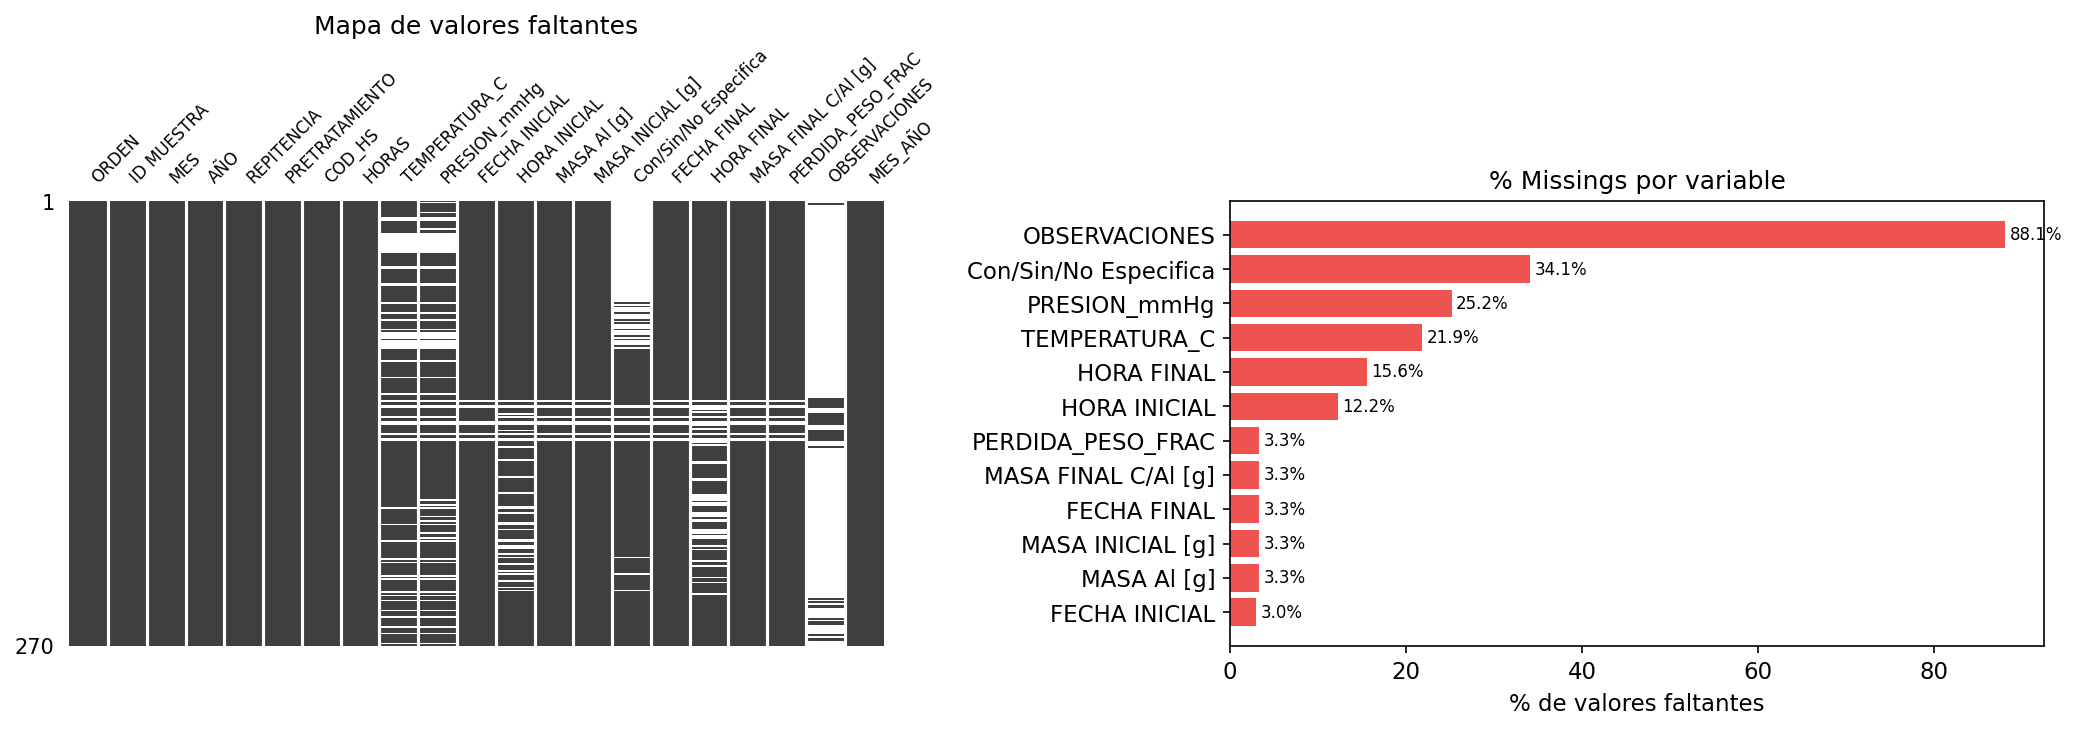

fig1 guardada.

Variables con missings:
TEMPERATURA_C             59
PRESION_mmHg              68
FECHA INICIAL              8
HORA INICIAL              33
MASA Al [g]                9
MASA INICIAL [g]           9
Con/Sin/No Especifica     92
FECHA FINAL                9
HORA FINAL                42
MASA FINAL C/Al [g]        9
PERDIDA_PESO_FRAC          9
OBSERVACIONES            238
dtype: int64


In [4]:
import missingno as msno

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: matriz de missings
msno.matrix(df_raw, ax=axes[0], sparkline=False, fontsize=8)
axes[0].set_title('Mapa de valores faltantes', fontsize=12)

# Panel derecho: % missings por variable
miss_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=True)
miss_pct = miss_pct[miss_pct > 0]
bars = axes[1].barh(miss_pct.index, miss_pct.values, color='#EF5350')
axes[1].set_xlabel('% de valores faltantes')
axes[1].set_title('% Missings por variable')
for i, v in enumerate(miss_pct.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig1_mapa_missings.png', bbox_inches='tight')
plt.show()
print("fig1 guardada.")
print("\nVariables con missings:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

In [5]:
# Detección de outliers por IQR en PERDIDA_PESO_FRAC
Q1 = df['PERDIDA_PESO_FRAC'].quantile(0.25)
Q3 = df['PERDIDA_PESO_FRAC'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['PERDIDA_PESO_FRAC'] < lower) |
    (df['PERDIDA_PESO_FRAC'] > upper)
].copy()

print(f"Rango IQR: [{lower:.4f}, {upper:.4f}]")
print(f"Outliers detectados: {len(outliers)}")
if len(outliers) > 0:
    cols_mostrar = ['ID MUESTRA', 'HORAS', 'PRETRATAMIENTO', 'MES_AÑO', 'PERDIDA_PESO_FRAC', 'OBSERVACIONES']
    cols_mostrar = [c for c in cols_mostrar if c in outliers.columns]
    print(outliers[cols_mostrar].to_string())

Rango IQR: [0.4638, 1.1993]
Outliers detectados: 25
    ID MUESTRA  HORAS  PRETRATAMIENTO         MES_AÑO  PERDIDA_PESO_FRAC                                                                          OBSERVACIONES
10   NOV24-BF1      6          FRESCO  Noviembre-2024           0.400332                                                                                    NaN
20   NOV24-CF1      6          FRESCO  Noviembre-2024           0.347370                                                                                    NaN
30   NOV24-AC1      6       CONGELADO  Noviembre-2024           0.291937                                                                                    NaN
31   NOV24-AC2     12       CONGELADO  Noviembre-2024           0.417425                                                                                    NaN
40   NOV24-BC1      6       CONGELADO  Noviembre-2024           0.310568                                                                            

In [6]:
import os
assert os.path.exists(FIG_DIR + 'fig1_mapa_missings.png'), "fig1 no generada"
print("✓ Task 1 OK — fig1_mapa_missings.png generada")

✓ Task 1 OK — fig1_mapa_missings.png generada


---
## Sección 2: EDA — Estadísticas descriptivas

In [7]:
import matplotlib.ticker as mticker

print("=== ESTADÍSTICAS GLOBALES ===")
print(df['PERDIDA_PESO_FRAC'].describe().round(4))

print("\n=== POR PRETRATAMIENTO ===")
desc_pt = df.groupby('PRETRATAMIENTO')['PERDIDA_PESO_FRAC'].describe().round(4)
print(desc_pt)

print("\n=== TABLA: MEDIA ± SD POR (PRETRATAMIENTO × HORAS) ===")
tabla = df.groupby(['PRETRATAMIENTO', 'HORAS'])['PERDIDA_PESO_FRAC'].agg(
    media='mean', sd='std', n='count'
).round(4)
print(tabla.to_string())

=== ESTADÍSTICAS GLOBALES ===
count    261.0000
mean       0.8062
std        0.1877
min        0.2618
25%        0.7396
50%        0.9125
75%        0.9235
max        0.9364
Name: PERDIDA_PESO_FRAC, dtype: float64

=== POR PRETRATAMIENTO ===
                count    mean     std     min     25%     50%     75%     max
PRETRATAMIENTO                                                               
CONGELADO        81.0  0.7835  0.2132  0.2618  0.7130  0.9153  0.9222  0.9317
FRESCO           90.0  0.8378  0.1507  0.3474  0.8348  0.9120  0.9256  0.9357
ULTRACONGELADO   90.0  0.7952  0.1943  0.2752  0.7251  0.9106  0.9207  0.9364

=== TABLA: MEDIA ± SD POR (PRETRATAMIENTO × HORAS) ===
                       media      sd  n
PRETRATAMIENTO HORAS                   
CONGELADO      6      0.3050  0.0348  9
               12     0.5028  0.1262  6
               18     0.7140  0.0291  9
               24     0.7822  0.0757  9
               36     0.9196  0.0037  6
               48     0.9229  0.

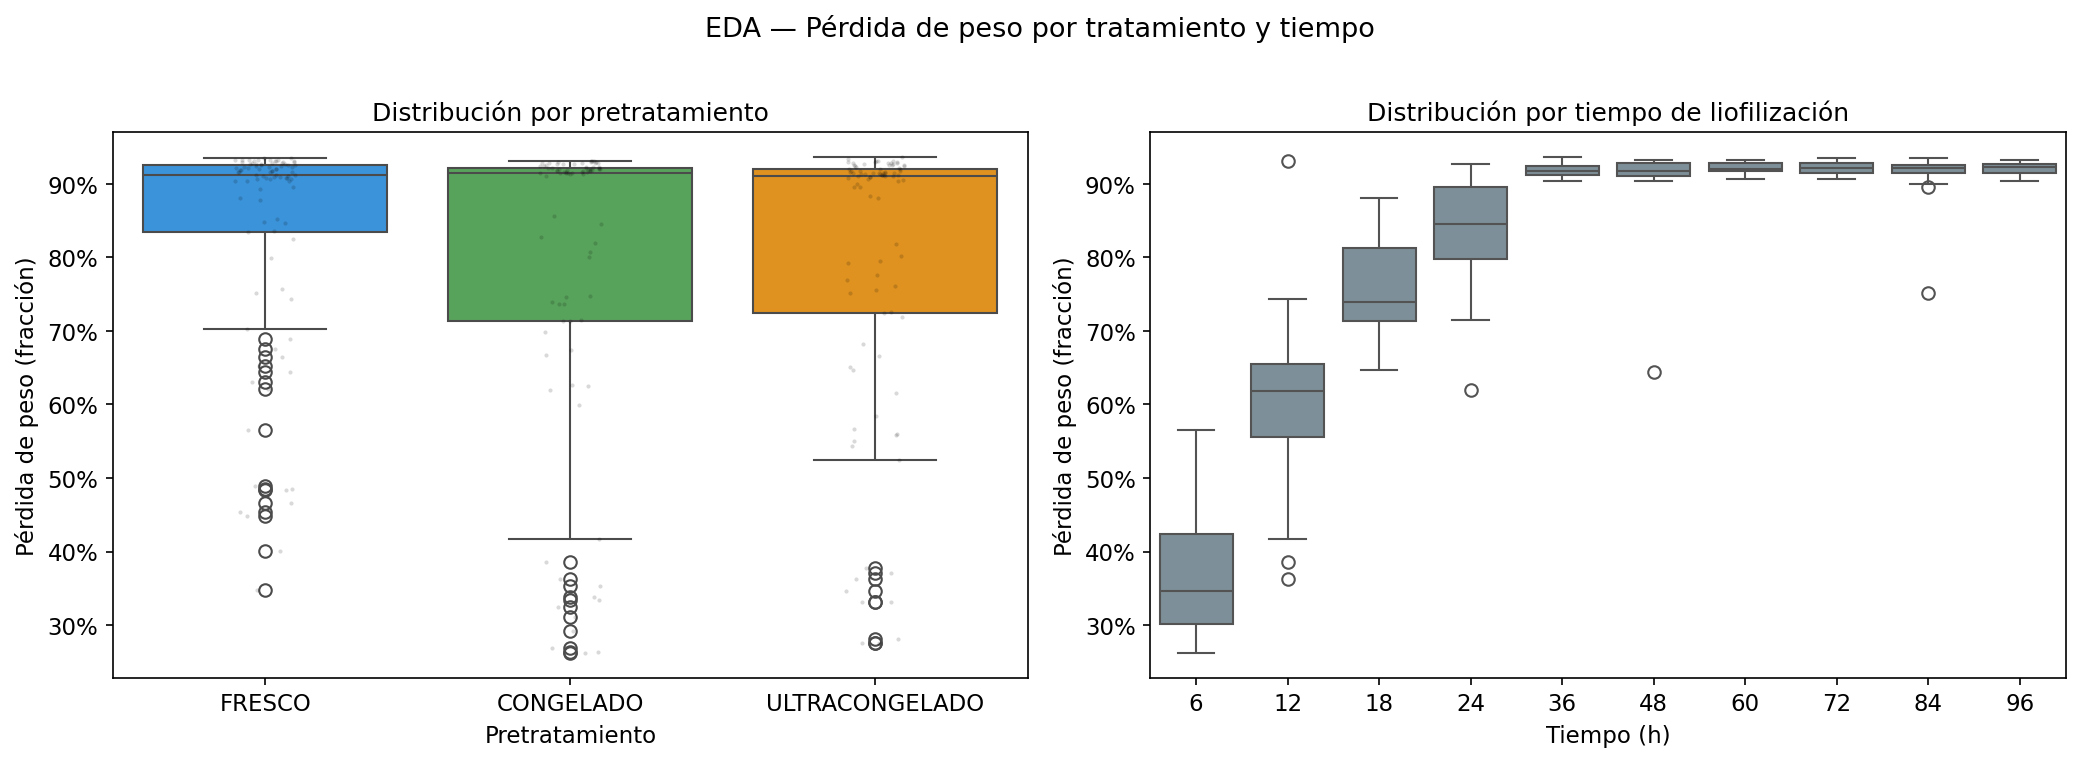

fig2 guardada.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_pt = ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']

# Boxplot por pretratamiento
sns.boxplot(data=df, x='PRETRATAMIENTO', y='PERDIDA_PESO_FRAC',
            order=orden_pt, palette=COLORES, ax=axes[0])
sns.stripplot(data=df, x='PRETRATAMIENTO', y='PERDIDA_PESO_FRAC',
              order=orden_pt, color='black', alpha=0.15, size=2, ax=axes[0])
axes[0].set_title('Distribución por pretratamiento')
axes[0].set_xlabel('Pretratamiento')
axes[0].set_ylabel('Pérdida de peso (fracción)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Boxplot por hora
sns.boxplot(data=df, x='HORAS', y='PERDIDA_PESO_FRAC', color='#78909C', ax=axes[1])
axes[1].set_title('Distribución por tiempo de liofilización')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('Pérdida de peso (fracción)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.suptitle('EDA — Pérdida de peso por tratamiento y tiempo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig2_descriptivas.png', bbox_inches='tight')
plt.show()
print("fig2 guardada.")

In [9]:
import os
assert os.path.exists(FIG_DIR + 'fig2_descriptivas.png'), "fig2 no generada"
assert len(tabla) == 30, f"Esperado 30 grupos (3×10), got {len(tabla)}"
print("Verificacion Task 2 OK — fig2_descriptivas.png generada")

Verificacion Task 2 OK — fig2_descriptivas.png generada


---
## Sección 3: Cinética de secado — Curvas medias ± SD

In [10]:
# Calcular media, SD, SE por PRETRATAMIENTO × HORAS
cinetica = df.groupby(['PRETRATAMIENTO', 'HORAS'])['PERDIDA_PESO_FRAC'].agg(
    media='mean',
    sd='std',
    n='count',
    se=lambda x: x.std() / np.sqrt(len(x))
).reset_index()

print("=== ESTADÍSTICAS CINÉTICAS POR PRETRATAMIENTO × HORAS ===")
print(cinetica.to_string(index=False))

=== ESTADÍSTICAS CINÉTICAS POR PRETRATAMIENTO × HORAS ===
PRETRATAMIENTO  HORAS    media       sd  n       se
     CONGELADO      6 0.305050 0.034774  9 0.011591
     CONGELADO     12 0.502780 0.126230  6 0.051533
     CONGELADO     18 0.713965 0.029108  9 0.009703
     CONGELADO     24 0.782214 0.075696  9 0.025232
     CONGELADO     36 0.919602 0.003738  6 0.001526
     CONGELADO     48 0.922879 0.006586  6 0.002689
     CONGELADO     60 0.921352 0.005578  9 0.001859
     CONGELADO     72 0.924848 0.007377  9 0.002459
     CONGELADO     84 0.919124 0.005198  9 0.001733
     CONGELADO     96 0.921435 0.004578  9 0.001526
        FRESCO      6 0.459995 0.060816  9 0.020272
        FRESCO     12 0.700981 0.093983  9 0.031328
        FRESCO     18 0.830857 0.035256  9 0.011752
        FRESCO     24 0.908283 0.016302  9 0.005434
        FRESCO     36 0.918434 0.009305  9 0.003102
        FRESCO     48 0.885295 0.090827  9 0.030276
        FRESCO     60 0.927357 0.005568  9 0.001856
      

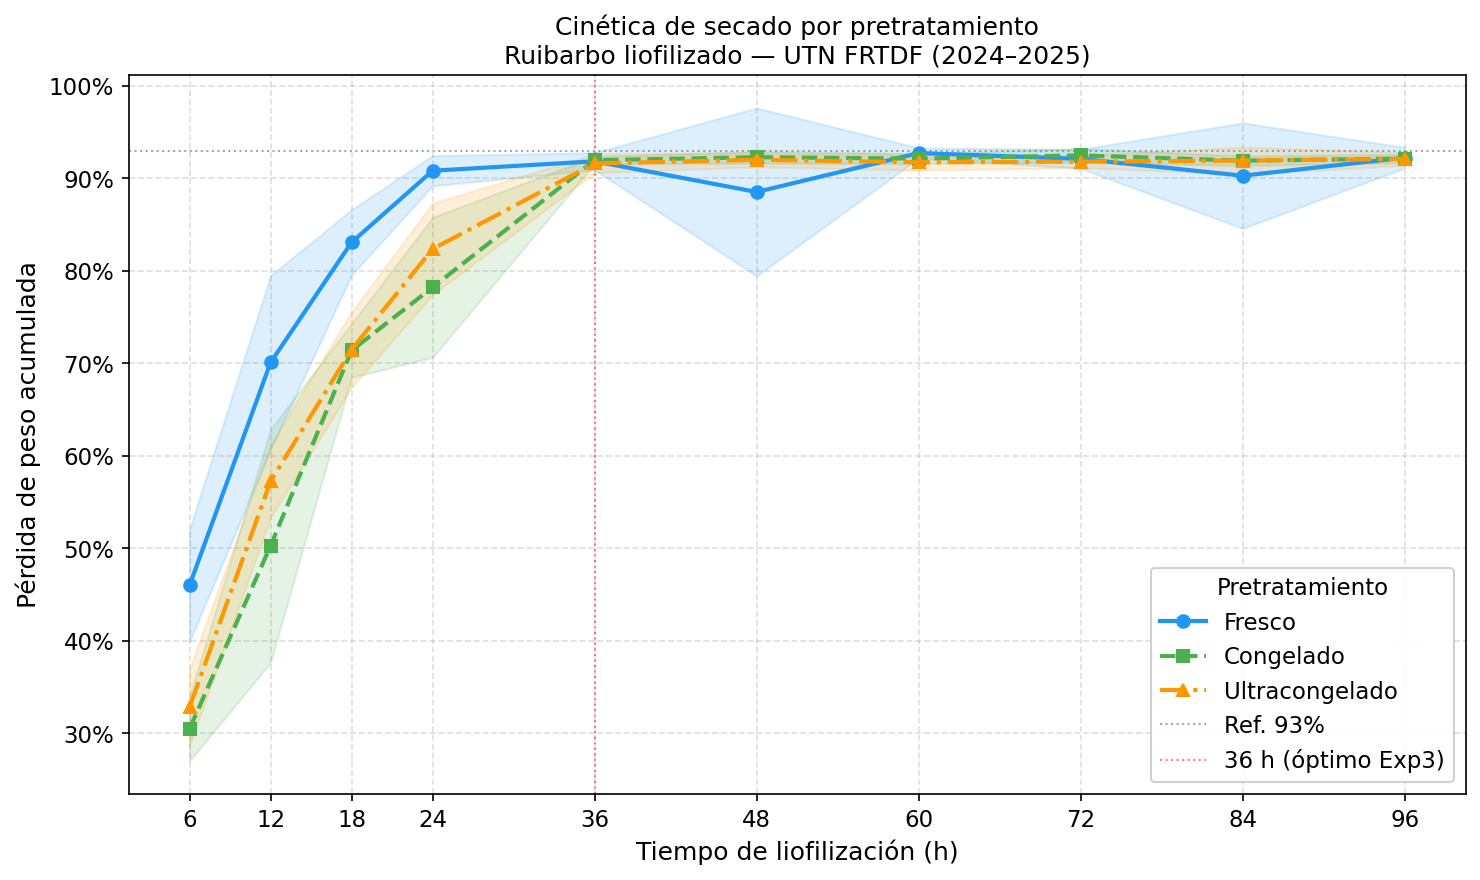

fig3 guardada.


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

orden_pt = ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']
marcadores = {'FRESCO': 'o', 'CONGELADO': 's', 'ULTRACONGELADO': '^'}
lineas = {'FRESCO': '-', 'CONGELADO': '--', 'ULTRACONGELADO': '-.'}

for pt in orden_pt:
    sub = cinetica[cinetica['PRETRATAMIENTO'] == pt].sort_values('HORAS')
    ax.plot(sub['HORAS'], sub['media'],
            color=COLORES[pt], marker=marcadores[pt],
            linestyle=lineas[pt], linewidth=2, markersize=6,
            label=pt.capitalize(), zorder=3)
    ax.fill_between(sub['HORAS'],
                    sub['media'] - sub['sd'],
                    sub['media'] + sub['sd'],
                    color=COLORES[pt], alpha=0.15, zorder=2)

# Líneas de referencia
ax.axhline(0.93, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Ref. 93%')
ax.axvline(36, color='red', linestyle=':', linewidth=1, alpha=0.5, label='36 h (óptimo Exp3)')

ax.set_xlabel('Tiempo de liofilización (h)', fontsize=12)
ax.set_ylabel('Pérdida de peso acumulada', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(sorted(df['HORAS'].unique()))
ax.set_title('Cinética de secado por pretratamiento\nRuibarbo liofilizado — UTN FRTDF (2024–2025)', fontsize=12)
ax.legend(title='Pretratamiento', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig3_cinetica_curvas.png', bbox_inches='tight', dpi=300)
plt.show()
print("fig3 guardada.")

In [12]:
import os
assert os.path.exists(FIG_DIR + 'fig3_cinetica_curvas.png'), "fig3 no generada"
assert len(cinetica) == 30, f"Esperado 30 grupos, got {len(cinetica)}"
print("Verificacion Task 3 OK — fig3_cinetica_curvas.png generada")
print(f"Media @ 36h por pretratamiento:")
for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    val = cinetica[(cinetica['PRETRATAMIENTO']==pt) & (cinetica['HORAS']==36)]['media'].values[0]
    print(f"  {pt}: {val*100:.2f}%")

Verificacion Task 3 OK — fig3_cinetica_curvas.png generada
Media @ 36h por pretratamiento:
  FRESCO: 91.84%
  CONGELADO: 91.96%
  ULTRACONGELADO: 91.62%


---
## Sección 4: Ajuste del Modelo de Page
*Modelo estándar de cinética de secado (Page, 1949): MR(t) = exp(−k·t^n)*

In [13]:
from scipy.optimize import curve_fit

def modelo_page(t, k, n):
    """Modelo de Page para cinética de secado: MR(t) = exp(-k * t^n)"""
    return np.exp(-k * t**n)

# MR = 1 - PERDIDA_PESO_FRAC (Moisture Ratio; asumimos M_equilibrio ≈ 0 en liofilización)
df['MR'] = 1 - df['PERDIDA_PESO_FRAC']

resultados_page = {}
for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    sub = df[df['PRETRATAMIENTO'] == pt].copy()
    t_data = sub['HORAS'].values.astype(float)
    MR_data = sub['MR'].values.astype(float)
    
    # Filtrar MR > 0 para evitar log(0) en la optimización
    mask = MR_data > 0
    t_data, MR_data = t_data[mask], MR_data[mask]
    
    try:
        popt, pcov = curve_fit(
            modelo_page, t_data, MR_data,
            p0=[0.05, 1.0],
            bounds=([0.001, 0.1], [10, 5]),
            maxfev=10000
        )
        k_opt, n_opt = popt
        perr = np.sqrt(np.diag(pcov))
        
        # Bondad de ajuste
        MR_pred = modelo_page(t_data, k_opt, n_opt)
        ss_res = np.sum((MR_data - MR_pred)**2)
        ss_tot = np.sum((MR_data - np.mean(MR_data))**2)
        r2 = 1 - ss_res / ss_tot
        rmse = np.sqrt(np.mean((MR_data - MR_pred)**2))
        
        resultados_page[pt] = {
            'k': k_opt, 'n': n_opt,
            'k_err': perr[0], 'n_err': perr[1],
            'R2': r2, 'RMSE': rmse,
            'n_datos': len(t_data)
        }
        print(f"{pt:18s}: k={k_opt:.4f}±{perr[0]:.4f}  n={n_opt:.4f}±{perr[1]:.4f}  R²={r2:.4f}  RMSE={rmse:.4f}")
    except Exception as e:
        print(f"ERROR en {pt}: {e}")

print("\n=== TABLA DE PARÁMETROS ===")
df_page = pd.DataFrame(resultados_page).T[['k','k_err','n','n_err','R2','RMSE']].round(4)
print(df_page.to_string())

FRESCO            : k=0.2564±0.0325  n=0.6074±0.0433  R²=0.7639  RMSE=0.0728
CONGELADO         : k=0.0869±0.0119  n=0.8780±0.0459  R²=0.9108  RMSE=0.0633
ULTRACONGELADO    : k=0.1067±0.0113  n=0.8323±0.0357  R²=0.9243  RMSE=0.0531

=== TABLA DE PARÁMETROS ===
                     k   k_err       n   n_err      R2    RMSE
FRESCO          0.2564  0.0325  0.6074  0.0433  0.7639  0.0728
CONGELADO       0.0869  0.0119  0.8780  0.0459  0.9108  0.0633
ULTRACONGELADO  0.1067  0.0113  0.8323  0.0357  0.9243  0.0531


---
## Sección 5: Análisis estadístico
*Comparación entre pretratamientos. Tests adaptativos según normalidad.*

In [14]:
import scipy.stats as stats_module

tiempos_clave = [24, 36, 48]

print("=== TEST SHAPIRO-WILK por grupo (pretratamiento × tiempo clave) ===")
print(f"{'Pretratamiento':20s} {'Horas':>6s} {'W':>8s} {'p-valor':>10s} {'Normal?':>8s}")
print("-" * 60)

resultados_norm = []
for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    for h in tiempos_clave:
        sub = df[(df['PRETRATAMIENTO'] == pt) & (df['HORAS'] == h)]['PERDIDA_PESO_FRAC']
        if len(sub) >= 3:
            W, p = stats_module.shapiro(sub)
            normal = p > 0.05
            resultados_norm.append({'Pretratamiento': pt, 'Horas': h, 'W': W, 'p': p, 'Normal': normal})
            print(f"{pt:20s} {h:>6d} {W:>8.4f} {p:>10.4f} {'Sí' if normal else 'NO':>8s}")

df_norm = pd.DataFrame(resultados_norm)
hay_no_normal = (~df_norm['Normal']).any()
print(f"\nAlgún grupo no normal: {hay_no_normal}")
print(f"Método a usar: {'Kruskal-Wallis + Dunn/Bonferroni' if hay_no_normal else 'ANOVA + Tukey HSD'}")

=== TEST SHAPIRO-WILK por grupo (pretratamiento × tiempo clave) ===
Pretratamiento        Horas        W    p-valor  Normal?
------------------------------------------------------------
FRESCO                   24   0.9044     0.2788       Sí
FRESCO                   36   0.9565     0.7609       Sí
FRESCO                   48   0.5009     0.0000       NO
CONGELADO                24   0.8631     0.1036       Sí
CONGELADO                36   0.9154     0.4728       Sí
CONGELADO                48   0.8177     0.0844       Sí
ULTRACONGELADO           24   0.8481     0.0710       Sí
ULTRACONGELADO           36   0.9192     0.3859       Sí
ULTRACONGELADO           48   0.8812     0.1618       Sí

Algún grupo no normal: True
Método a usar: Kruskal-Wallis + Dunn/Bonferroni


In [15]:
import pingouin as pg

print("=== COMPARACIÓN ENTRE PRETRATAMIENTOS POR TIEMPO CLAVE ===\n")
resultados_test = []

for h in tiempos_clave:
    grupos = [
        df[(df['PRETRATAMIENTO'] == pt) & (df['HORAS'] == h)]['PERDIDA_PESO_FRAC'].values
        for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']
    ]

    if hay_no_normal:
        stat, p = stats_module.kruskal(*grupos)
        metodo = 'Kruskal-Wallis'
    else:
        stat, p = stats_module.f_oneway(*grupos)
        metodo = 'ANOVA one-way'

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    resultados_test.append({'Horas': h, 'Método': metodo, 'Estadístico': round(stat,3), 'p-valor': round(p,4), 'Sig': sig})
    print(f"{h}h — {metodo}: stat={stat:.3f}, p={p:.4f} {sig}")

df_test = pd.DataFrame(resultados_test)
print()

# Post-hoc comparaciones pareadas
print("=== POST-HOC: COMPARACIONES PAREADAS ===")
for h in tiempos_clave:
    sub_h = df[df['HORAS'] == h][['PRETRATAMIENTO', 'PERDIDA_PESO_FRAC']].copy()
    print(f"\n--- {h} horas ---")
    if hay_no_normal:
        ph = pg.pairwise_tests(data=sub_h, dv='PERDIDA_PESO_FRAC',
                               between='PRETRATAMIENTO',
                               parametric=False, padjust='bonf')
    else:
        ph = pg.pairwise_tukey(data=sub_h, dv='PERDIDA_PESO_FRAC',
                               between='PRETRATAMIENTO')
    cols = [c for c in ['A', 'B', 'p-unc', 'p-corr', 'hedges'] if c in ph.columns]
    print(ph[cols].to_string(index=False))

=== COMPARACIÓN ENTRE PRETRATAMIENTOS POR TIEMPO CLAVE ===

24h — Kruskal-Wallis: stat=15.633, p=0.0004 ***
36h — Kruskal-Wallis: stat=1.334, p=0.5131 ns
48h — Kruskal-Wallis: stat=3.382, p=0.1843 ns

=== POST-HOC: COMPARACIONES PAREADAS ===

--- 24 horas ---
        A              B    hedges
CONGELADO         FRESCO -2.192893
CONGELADO ULTRACONGELADO -0.617479
   FRESCO ULTRACONGELADO  2.187168

--- 36 horas ---
        A              B   hedges
CONGELADO         FRESCO 0.143546
CONGELADO ULTRACONGELADO 0.386610
   FRESCO ULTRACONGELADO 0.219543

--- 48 horas ---
        A              B    hedges
CONGELADO         FRESCO  0.495647
CONGELADO ULTRACONGELADO  0.361086
   FRESCO ULTRACONGELADO -0.514084


In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ANOVA tipo II: efecto de pretratamiento, tiempo y mes (bloque)
modelo_ols = smf.ols(
    'PERDIDA_PESO_FRAC ~ C(PRETRATAMIENTO) + C(HORAS) + C(MES_AÑO)',
    data=df
).fit()
tabla_anova = sm.stats.anova_lm(modelo_ols, typ=2)

print("=== ANOVA TIPO II (pretratamiento + tiempo + mes) ===")
print(tabla_anova.round(4))
print(f"\nR² del modelo: {modelo_ols.rsquared:.4f}")
print(f"R² ajustado:   {modelo_ols.rsquared_adj:.4f}")

=== ANOVA TIPO II (pretratamiento + tiempo + mes) ===
                   sum_sq     df         F  PR(>F)
C(PRETRATAMIENTO)  0.1437    2.0   25.1751  0.0000
C(HORAS)           8.2978    9.0  322.9679  0.0000
C(MES_AÑO)         0.0132    2.0    2.3195  0.1005
Residual           0.7051  247.0       NaN     NaN

R² del modelo: 0.9230
R² ajustado:   0.9190


In [17]:
assert len(df_test) == 3, f"Deben testearse 3 tiempos, got {len(df_test)}"
assert 'p-valor' in df_test.columns
print("Verificacion Task 5 OK")
print("\nResumen de significancia:")
for _, row in df_test.iterrows():
    print(f"  {row['Horas']}h: p={row['p-valor']:.4f} {row['Sig']}")

Verificacion Task 5 OK

Resumen de significancia:
  24h: p=0.0004 ***
  36h: p=0.5131 ns
  48h: p=0.1843 ns


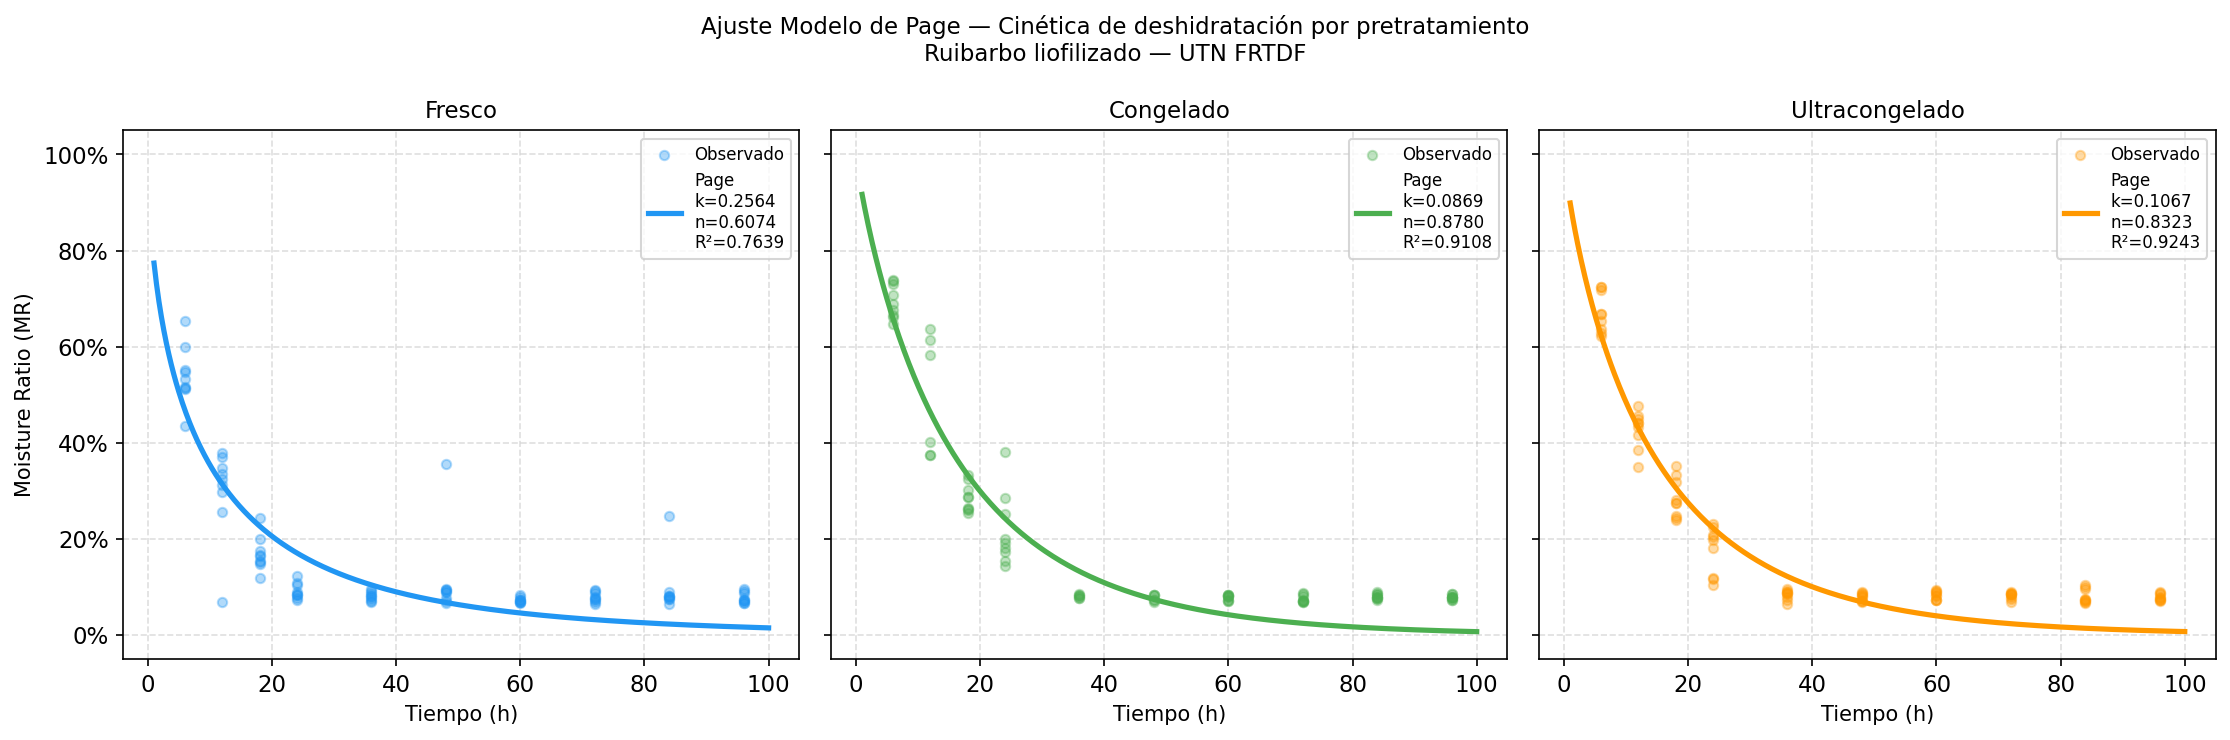

fig4 guardada.


In [18]:
t_fit = np.linspace(1, 100, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, pt in enumerate(['FRESCO', 'CONGELADO', 'ULTRACONGELADO']):
    ax = axes[i]
    sub = df[df['PRETRATAMIENTO'] == pt]
    
    # Datos observados
    ax.scatter(sub['HORAS'], sub['MR'],
               color=COLORES[pt], alpha=0.35, s=20,
               label='Observado', zorder=3)
    
    # Curva ajustada
    if pt in resultados_page:
        r = resultados_page[pt]
        MR_fit = modelo_page(t_fit, r['k'], r['n'])
        ax.plot(t_fit, MR_fit,
                color=COLORES[pt], linewidth=2.5,
                label=f"Page\nk={r['k']:.4f}\nn={r['n']:.4f}\nR²={r['R2']:.4f}")
    
    ax.set_title(f'{pt.capitalize()}', fontsize=11)
    ax.set_xlabel('Tiempo (h)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Moisture Ratio (MR)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Ajuste Modelo de Page — Cinética de deshidratación por pretratamiento\nRuibarbo liofilizado — UTN FRTDF', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig4_modelo_page.png', bbox_inches='tight')
plt.show()
print("fig4 guardada.")

In [19]:
import os
assert os.path.exists(FIG_DIR + 'fig4_modelo_page.png'), "fig4 no generada"
assert len(resultados_page) == 3, f"Deben ajustarse 3 modelos, got {len(resultados_page)}"
for pt, r in resultados_page.items():
    assert r['R2'] > 0.70, f"R² bajo para {pt}: {r['R2']:.4f} — revisar datos o bounds"
    print(f"  {pt}: R²={r['R2']:.4f} (OK)")
print("Verificacion Task 4 OK")
# NOTA: R2 de FRESCO (0.764) es inferior al de CONGELADO/ULTRACONGELADO (>0.91)
# Interpretacion: el pre-congelado homogeniza la estructura celular del ruibarbo,
# resultando en una cinetica de secado mas predecible (mejor ajuste al Modelo de Page).


  FRESCO: R²=0.7639 (OK)
  CONGELADO: R²=0.9108 (OK)
  ULTRACONGELADO: R²=0.9243 (OK)
Verificacion Task 4 OK


---
## Sección 6: Detección del tiempo óptimo de liofilización
*Criterio: cambio relativo entre tiempos consecutivos ≤ 1%*

In [20]:
print("=== DETECCION DE PLATEAU (criterio: delta relativo <= 1%) ===\n")
tiempo_optimo = {}

for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    sub = cinetica[cinetica['PRETRATAMIENTO'] == pt].sort_values('HORAS')
    horas = sub['HORAS'].values
    medias = sub['media'].values

    # Derivada discreta (cambio relativo entre tiempos consecutivos)
    delta_rel = np.abs(np.diff(medias) / medias[:-1])
    horas_mid = horas[1:]

    # Primer tiempo donde delta <= 1%
    plateau_idx = np.where(delta_rel <= 0.01)[0]
    if len(plateau_idx) > 0:
        t_opt = horas_mid[plateau_idx[0]]
        val_opt = medias[np.where(horas == t_opt)[0][0]]
        tiempo_optimo[pt] = {
            'horas': int(t_opt),
            'perdida_media': float(val_opt),
            'delta_rel': float(delta_rel[plateau_idx[0]])
        }
        print(f"{pt:18s}: plateau a las {t_opt:2.0f}h  (delta={delta_rel[plateau_idx[0]]:.3%}, perdida={val_opt:.3%})")
    else:
        tiempo_optimo[pt] = {'horas': None, 'perdida_media': None, 'delta_rel': None}
        print(f"{pt:18s}: plateau NO detectado con criterio 1%")

print("\n=== TABLA RESUMEN PLATEAU ===")
for pt, v in tiempo_optimo.items():
    if v['horas']:
        print(f"  {pt}: {v['horas']}h | perdida media: {v['perdida_media']*100:.2f}% | delta: {v['delta_rel']*100:.3f}%")

=== DETECCION DE PLATEAU (criterio: delta relativo <= 1%) ===

FRESCO            : plateau a las 72h  (delta=0.676%, perdida=92.109%)
CONGELADO         : plateau a las 48h  (delta=0.356%, perdida=92.288%)
ULTRACONGELADO    : plateau a las 48h  (delta=0.426%, perdida=92.009%)

=== TABLA RESUMEN PLATEAU ===
  FRESCO: 72h | perdida media: 92.11% | delta: 0.676%
  CONGELADO: 48h | perdida media: 92.29% | delta: 0.356%
  ULTRACONGELADO: 48h | perdida media: 92.01% | delta: 0.426%


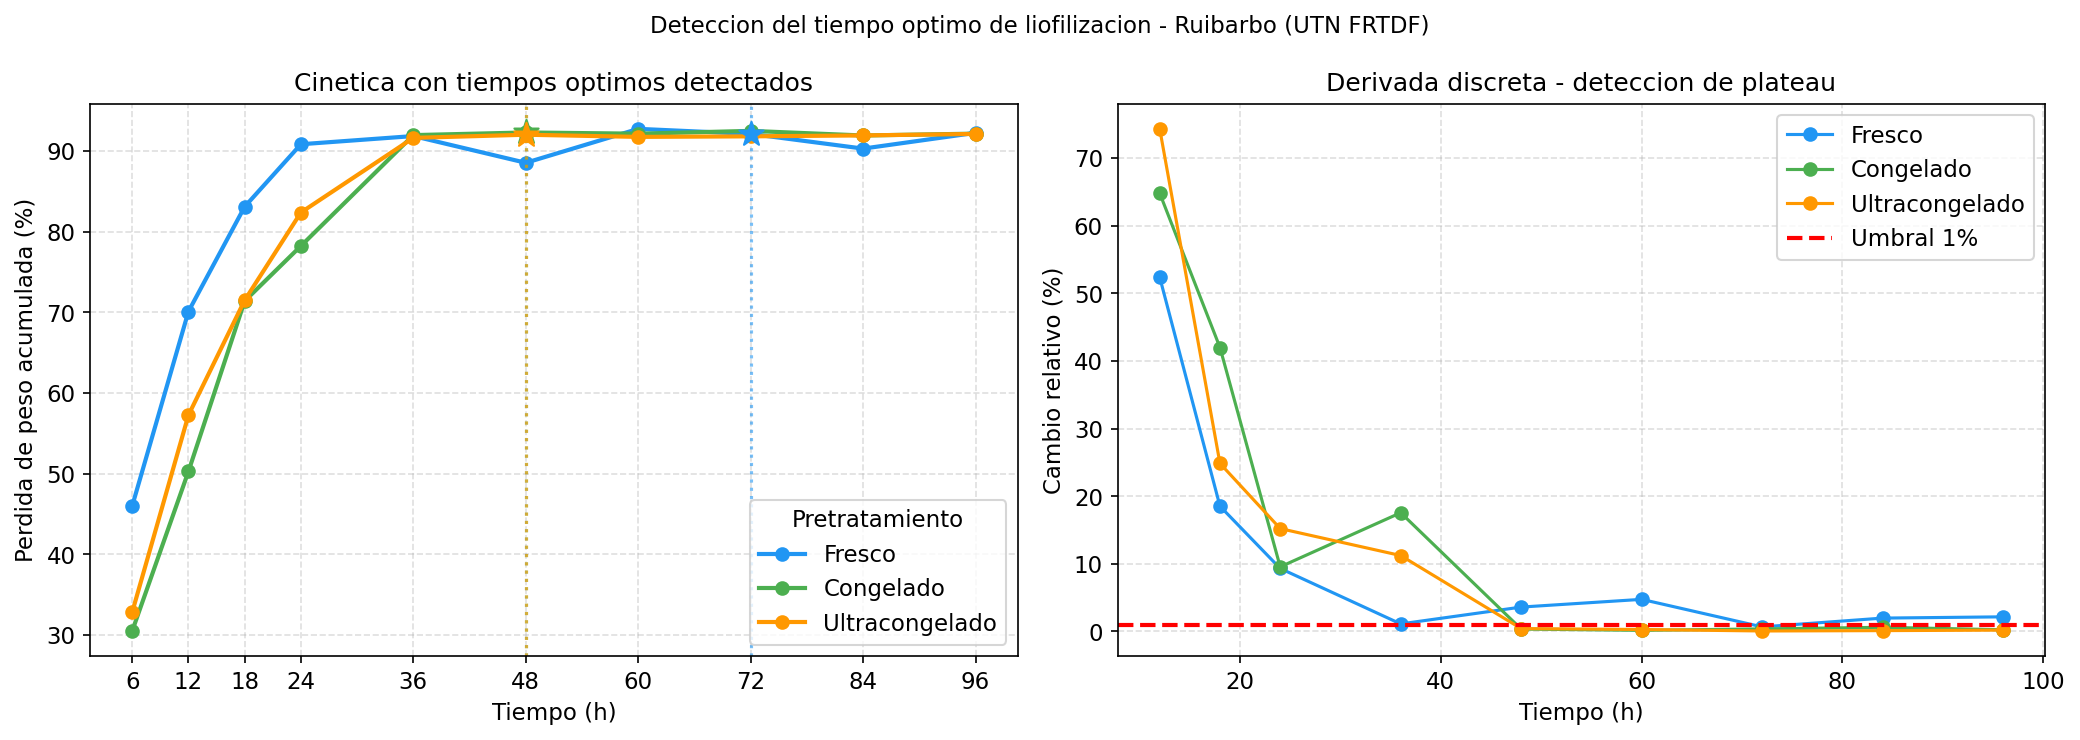

fig5 guardada.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: curvas con marcadores de plateau
ax = axes[0]
for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    sub = cinetica[cinetica['PRETRATAMIENTO'] == pt].sort_values('HORAS')
    ax.plot(sub['HORAS'], sub['media'] * 100,
            color=COLORES[pt], marker='o', linewidth=2, label=pt.capitalize())
    v = tiempo_optimo[pt]
    if v['horas']:
        ax.axvline(v['horas'], color=COLORES[pt], linestyle=':', alpha=0.6, linewidth=1.5)
        ax.scatter([v['horas']], [v['perdida_media'] * 100],
                   color=COLORES[pt], s=150, zorder=5, marker='*')

ax.set_xlabel('Tiempo (h)', fontsize=11)
ax.set_ylabel('Perdida de peso acumulada (%)', fontsize=11)
ax.set_title('Cinetica con tiempos optimos detectados')
ax.legend(title='Pretratamiento')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xticks(sorted(df['HORAS'].unique()))

# Panel derecho: derivada discreta
ax2 = axes[1]
for pt in ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']:
    sub = cinetica[cinetica['PRETRATAMIENTO'] == pt].sort_values('HORAS')
    horas = sub['HORAS'].values
    medias = sub['media'].values
    delta_rel = np.abs(np.diff(medias) / medias[:-1]) * 100
    ax2.plot(horas[1:], delta_rel, color=COLORES[pt], marker='o', linewidth=1.5, label=pt.capitalize())

ax2.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Umbral 1%')
ax2.set_xlabel('Tiempo (h)', fontsize=11)
ax2.set_ylabel('Cambio relativo (%)', fontsize=11)
ax2.set_title('Derivada discreta - deteccion de plateau')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Deteccion del tiempo optimo de liofilizacion - Ruibarbo (UTN FRTDF)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig5_derivadas_plateau.png', bbox_inches='tight')
plt.show()
print("fig5 guardada.")

In [22]:
import os
assert os.path.exists(FIG_DIR + 'fig5_derivadas_plateau.png'), "fig5 no generada"
assert len(tiempo_optimo) == 3
detectados = [pt for pt, v in tiempo_optimo.items() if v['horas'] is not None]
print(f"Plateau detectado en: {detectados}")
print("Verificacion Task 6 OK")

Plateau detectado en: ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']
Verificacion Task 6 OK


---
## Sección 7: Condiciones operacionales — T° y Presión del equipo
*Análisis del subconjunto con T° y P° registradas (RIFICOR LT-8). Exploratorio.*

In [23]:
import scipy.stats as stats_module

df_op = df.dropna(subset=['TEMPERATURA_C', 'PRESION_mmHg']).copy()
print(f"Subconjunto T+P disponibles: {len(df_op)}/{len(df)} obs ({len(df_op)/len(df)*100:.1f}%)")
print("\nPor pretratamiento:")
print(df_op['PRETRATAMIENTO'].value_counts())

print("\n=== ESTADISTICAS OPERACIONALES ===")
print("\nT condensador (C):")
print(df_op.groupby('PRETRATAMIENTO')['TEMPERATURA_C'].describe().round(2))
print("\nPresion (mmHg):")
print(df_op.groupby('PRETRATAMIENTO')['PRESION_mmHg'].describe().round(3))

# Correlaciones de Spearman
r_T, p_T = stats_module.spearmanr(df_op['TEMPERATURA_C'], df_op['PERDIDA_PESO_FRAC'])
r_P, p_P = stats_module.spearmanr(df_op['PRESION_mmHg'], df_op['PERDIDA_PESO_FRAC'])
print(f"\nSpearman T vs Perdida: r={r_T:.4f}, p={p_T:.4f}")
print(f"Spearman P vs Perdida: r={r_P:.4f}, p={p_P:.4f}")

Subconjunto T+P disponibles: 202/261 obs (77.4%)

Por pretratamiento:
PRETRATAMIENTO
ULTRACONGELADO    71
CONGELADO         69
FRESCO            62
Name: count, dtype: int64

=== ESTADISTICAS OPERACIONALES ===

T condensador (C):
                count   mean   std   min   25%   50%   75%   max
PRETRATAMIENTO                                                  
CONGELADO        69.0 -37.72  1.14 -40.0 -38.0 -38.0 -37.0 -35.0
FRESCO           62.0 -37.66  1.01 -40.0 -38.0 -38.0 -37.0 -36.0
ULTRACONGELADO   71.0 -39.54  0.83 -41.0 -40.0 -40.0 -39.0 -37.0

Presion (mmHg):
                count   mean    std    min    25%    50%    75%    max
PRETRATAMIENTO                                                        
CONGELADO        69.0  1.410  0.255  1.164  1.268  1.329  1.384  2.136
FRESCO           62.0  1.379  0.334  1.116  1.216  1.268  1.384  2.328
ULTRACONGELADO   71.0  1.541  0.305  1.216  1.384  1.448  1.576  2.432

Spearman T vs Perdida: r=0.1180, p=0.0945
Spearman P vs Perdida: r=-0.13

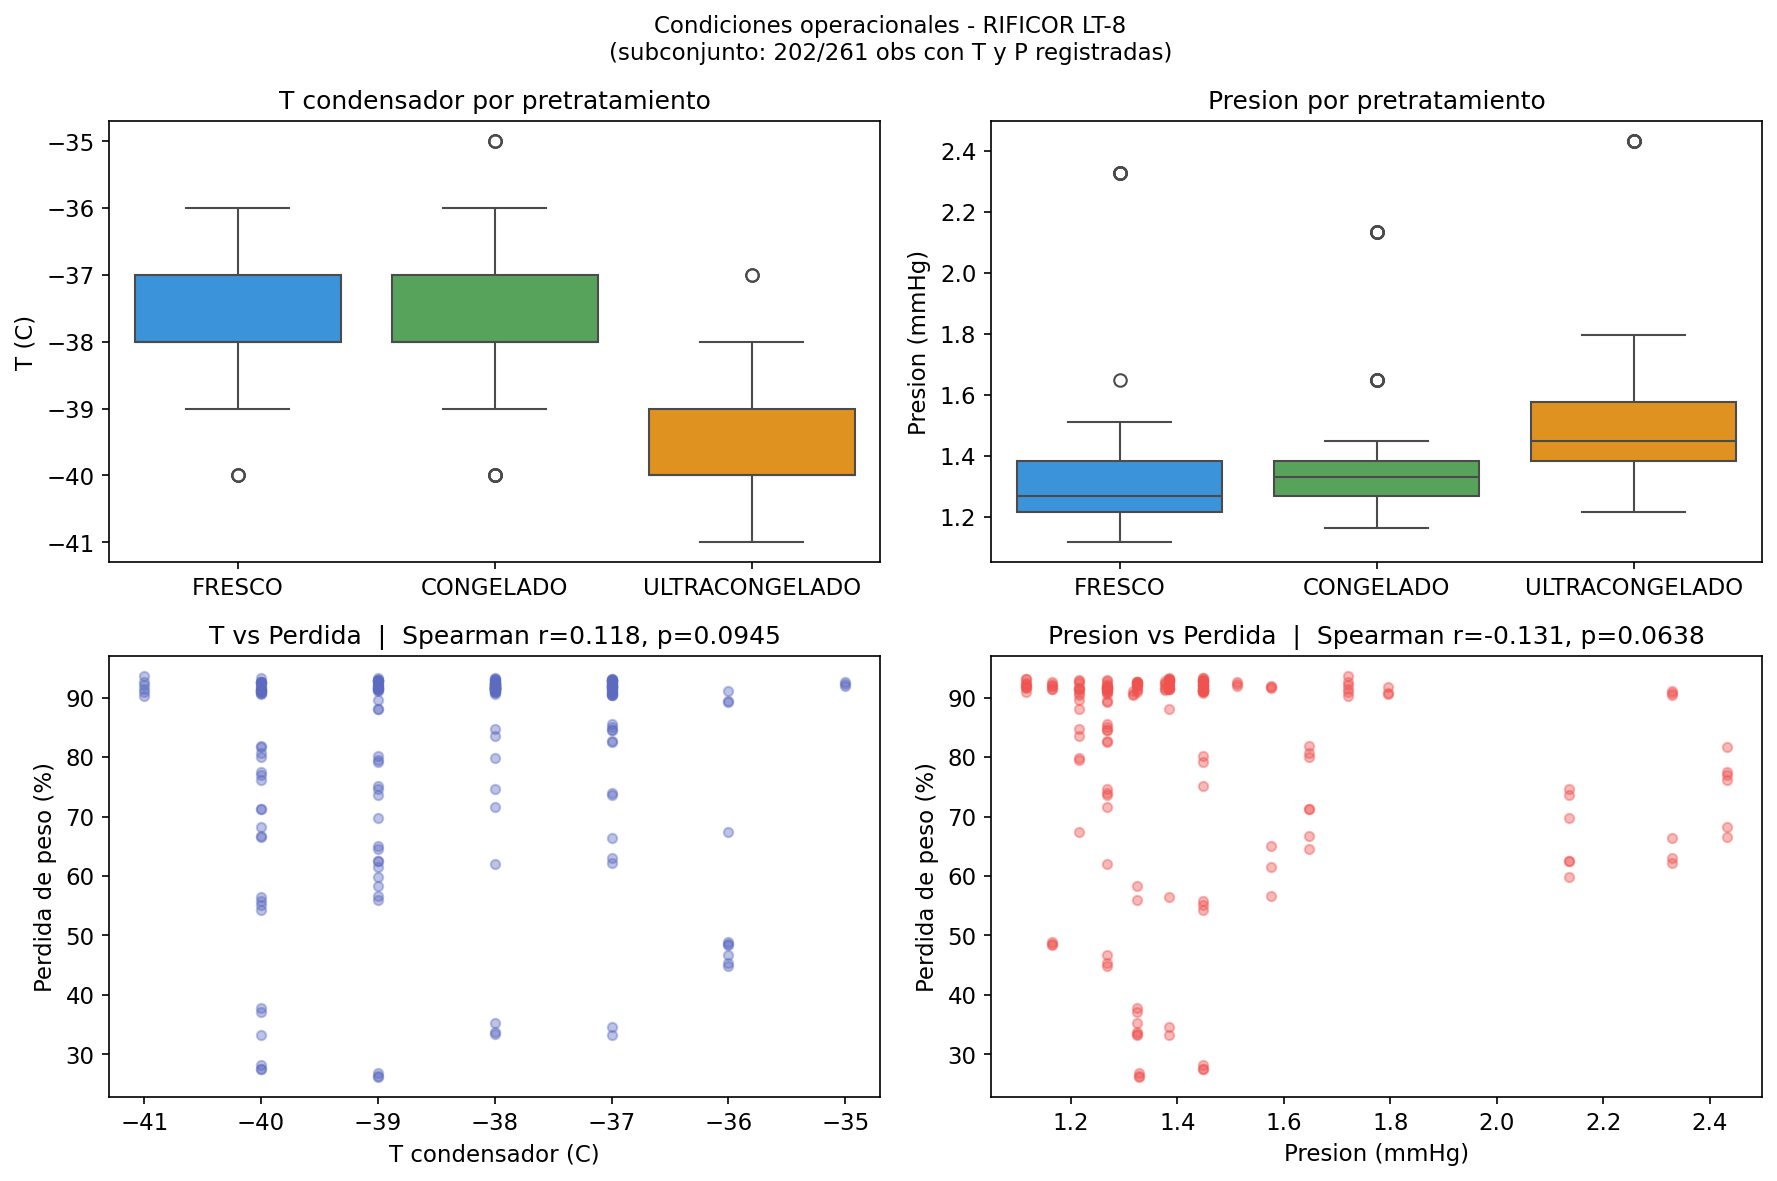

fig6 guardada.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
orden_pt = ['FRESCO', 'CONGELADO', 'ULTRACONGELADO']

import warnings; warnings.filterwarnings('ignore')

# T por pretratamiento
sns.boxplot(data=df_op, x='PRETRATAMIENTO', y='TEMPERATURA_C',
            order=orden_pt, palette=COLORES, ax=axes[0,0])
axes[0,0].set_title('T condensador por pretratamiento')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('T (C)')

# P por pretratamiento
sns.boxplot(data=df_op, x='PRETRATAMIENTO', y='PRESION_mmHg',
            order=orden_pt, palette=COLORES, ax=axes[0,1])
axes[0,1].set_title('Presion por pretratamiento')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Presion (mmHg)')

# Scatter T vs Perdida
axes[1,0].scatter(df_op['TEMPERATURA_C'], df_op['PERDIDA_PESO_FRAC'] * 100,
                  alpha=0.4, s=20, color='#5C6BC0')
axes[1,0].set_xlabel('T condensador (C)')
axes[1,0].set_ylabel('Perdida de peso (%)')
axes[1,0].set_title(f'T vs Perdida  |  Spearman r={r_T:.3f}, p={p_T:.4f}')

# Scatter P vs Perdida
axes[1,1].scatter(df_op['PRESION_mmHg'], df_op['PERDIDA_PESO_FRAC'] * 100,
                  alpha=0.4, s=20, color='#EF5350')
axes[1,1].set_xlabel('Presion (mmHg)')
axes[1,1].set_ylabel('Perdida de peso (%)')
axes[1,1].set_title(f'Presion vs Perdida  |  Spearman r={r_P:.3f}, p={p_P:.4f}')

plt.suptitle(f'Condiciones operacionales - RIFICOR LT-8\n(subconjunto: {len(df_op)}/{len(df)} obs con T y P registradas)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig6_operacionales.png', bbox_inches='tight')
plt.show()
print("fig6 guardada.")

In [25]:
import os
assert os.path.exists(FIG_DIR + 'fig6_operacionales.png'), "fig6 no generada"
print(f"Verificacion Task 7 OK")
print(f"  T vs Perdida: r={r_T:.3f} ({'significativo' if p_T < 0.05 else 'no significativo'}, p={p_T:.4f})")
print(f"  P vs Perdida: r={r_P:.3f} ({'significativo' if p_P < 0.05 else 'no significativo'}, p={p_P:.4f})")

Verificacion Task 7 OK
  T vs Perdida: r=0.118 (no significativo, p=0.0945)
  P vs Perdida: r=-0.131 (no significativo, p=0.0638)
